[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brilliantbeaver/alexpose/blob/main/experiments/sjepa/gavd6/04_pretrain_sjepa_on_normal.ipynb)

# 04. Train S-JEPA: normal first, then progressive gait fine-tuning

Train the view encoder and predictor to completion on normal gait first. Only then continue the same model through Parkinson's, stroke, myopathic, and cerebral-palsy stages, with balanced replay, VICReg anti-collapse regularization, and bounded group separation.

**Research use only.** This tutorial does not diagnose a person or validate a clinical device.

**Run it:** locally, use `uv sync` then `uv run jupyter lab` from this folder. In Colab, use the badge and run the setup cell. Restart the kernel after changing `experiments/sjepa/gavd6/.env`.

**Hard constraints:** no motion-aware mask is computed; only indices 11, 12, and 23–32 can be hidden; the Stage 0 checkpoint is saved before any condition data is loaded for optimization.


In [1]:
from pathlib import Path
import os
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/brilliantbeaver/alexpose.git"

if IN_COLAB:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "numpy", "pandas", "scipy", "scikit-learn", "matplotlib",
        "seaborn", "torch", "tqdm", "python-dotenv", "yt-dlp[default]",
        "opencv-python-headless", "mediapipe<1", "joblib", "pyarrow",
    ])
    clone_dir = Path("/content/alexpose")
    if not (clone_dir / ".git").exists():
        subprocess.check_call(["git", "clone", "--depth", "1", REPO_URL, str(clone_dir)])
    os.chdir(clone_dir)


def find_project_root(start=None):
    env_root = os.getenv("ALEXPOSE_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
        print(f"Ignoring invalid ALEXPOSE_ROOT: {candidate}")
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TUTORIAL_DIR = PROJECT_ROOT / "experiments" / "sjepa" / "gavd6"

try:
    from dotenv import load_dotenv
    load_dotenv(TUTORIAL_DIR / ".env", override=False)
    load_dotenv(PROJECT_ROOT / ".env", override=False)
except Exception:
    pass

MODE = os.getenv("GAVD_MODE", "smoke").strip().lower()
if MODE not in {"smoke", "real"}:
    raise ValueError("GAVD_MODE must be smoke or real")
if MODE == "smoke":
    print(
        "SMOKE MODE: hand-authored motions test code paths only. "
        "They have no pathophysiological or clinical validity."
    )

DATA_GAVD_DIR = Path(
    os.getenv("GAVD_DATA_GAVD_DIR", PROJECT_ROOT / "data" / "gavd")
).expanduser()
if not DATA_GAVD_DIR.is_dir():
    raise FileNotFoundError(f"GAVD CSV directory is missing: {DATA_GAVD_DIR}")

YOUTUBE_DIR = Path(
    os.getenv("GAVD_YOUTUBE_DIR", TUTORIAL_DIR / "work" / "youtube")
).expanduser()
CACHE_DIR = Path(
    os.getenv("GAVD_CACHE_DIR", TUTORIAL_DIR / "work" / "cache")
).expanduser()
ARTIFACT_ROOT = Path(
    os.getenv("GAVD_ARTIFACT_DIR", TUTORIAL_DIR / "work" / "artifacts")
).expanduser()
ARTIFACT_DIR = ARTIFACT_ROOT / MODE
POSE_DIR = ARTIFACT_DIR / "poses"

for folder in [CACHE_DIR, ARTIFACT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_DIR / "xdg-cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
from IPython.display import SVG, display


def show_tutorial_svg(filename):
    '''Render a repository SVG reliably in local Jupyter and Colab.'''
    path = TUTORIAL_DIR / "images" / filename
    if not path.exists():
        raise FileNotFoundError(
            f"Missing tutorial figure {path}. Clone the full alexpose repository."
        )
    display(SVG(filename=str(path)))

print(f"mode: {MODE}")
print(f"project: {PROJECT_ROOT}")
print(f"GAVD CSVs: {DATA_GAVD_DIR}")
print(f"YouTube cache: {YOUTUBE_DIR}")
print(f"artifacts: {ARTIFACT_DIR}")


mode: real
project: /Users/theodoremui/dev/alexpose
GAVD CSVs: /Users/theodoremui/dev/alexpose/data/gavd
YouTube cache: /Users/theodoremui/dev/alexpose/experiments/sjepa/gavd6/work/youtube
artifacts: /Users/theodoremui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real


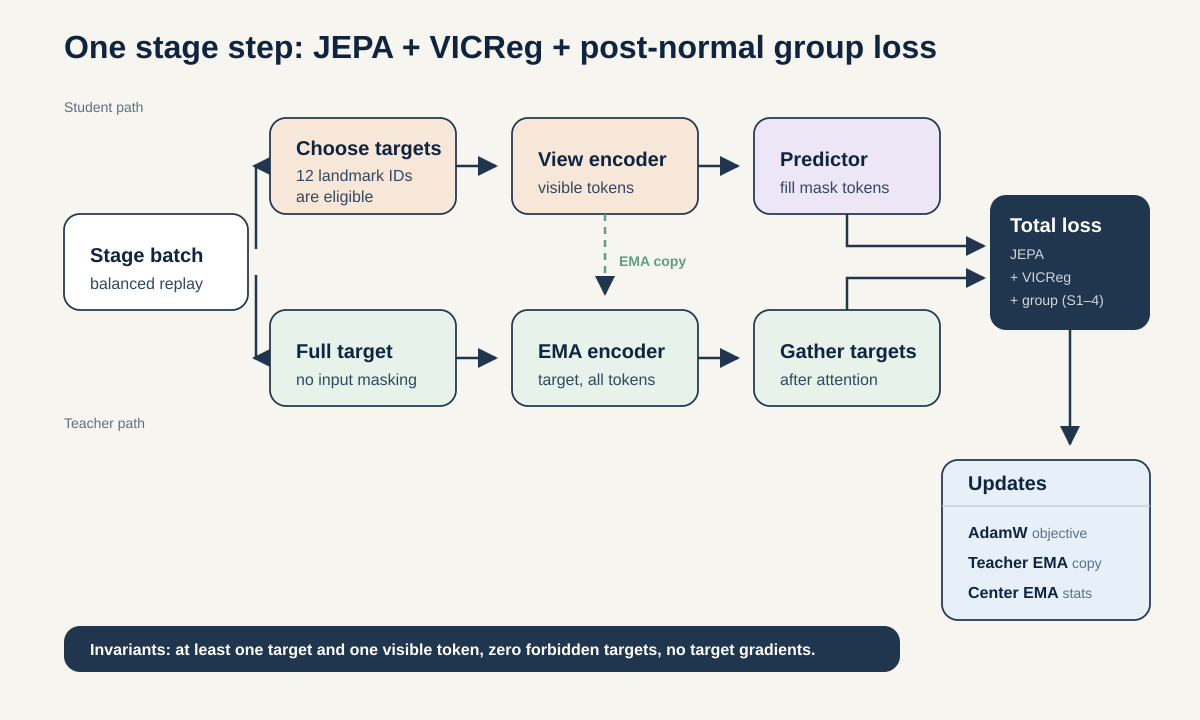

In [2]:
show_tutorial_svg("06_training_step.svg")


In [3]:
BLAZEPOSE_33 = [
    "NOSE", "LEFT_EYE_INNER", "LEFT_EYE", "LEFT_EYE_OUTER",
    "RIGHT_EYE_INNER", "RIGHT_EYE", "RIGHT_EYE_OUTER", "LEFT_EAR",
    "RIGHT_EAR", "MOUTH_LEFT", "MOUTH_RIGHT", "LEFT_SHOULDER",
    "RIGHT_SHOULDER", "LEFT_ELBOW", "RIGHT_ELBOW", "LEFT_WRIST",
    "RIGHT_WRIST", "LEFT_PINKY", "RIGHT_PINKY", "LEFT_INDEX",
    "RIGHT_INDEX", "LEFT_THUMB", "RIGHT_THUMB", "LEFT_HIP",
    "RIGHT_HIP", "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE",
    "RIGHT_ANKLE", "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX",
    "RIGHT_FOOT_INDEX",
]
MASK_KEYPOINTS = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
MASK_KEYPOINT_NAMES = [
    "LEFT_SHOULDER", "RIGHT_SHOULDER", "LEFT_HIP", "RIGHT_HIP",
    "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE", "RIGHT_ANKLE",
    "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX", "RIGHT_FOOT_INDEX",
]
assert MASK_KEYPOINTS == sorted(set(MASK_KEYPOINTS))
assert [BLAZEPOSE_33[i] for i in MASK_KEYPOINTS] == MASK_KEYPOINT_NAMES


In [4]:
CONDITIONS = ["normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"]
PROGRESSIVE_CONDITIONS = CONDITIONS[1:]
COHORT_ROOT = PROJECT_ROOT / "data" / "gavd"
EXPECTED_SEQUENCE_COUNTS = {
    "normal": 12,
    "parkinsons": 9,
    "stroke": 12,
    "myopathic": 47,
    "cerebralpalsy": 16,
}
EXPECTED_SEQUENCE_IDS = {
    condition: {path.stem for path in (COHORT_ROOT / condition).glob("*.csv")}
    for condition in CONDITIONS
}
for condition, expected_count in EXPECTED_SEQUENCE_COUNTS.items():
    actual_count = len(EXPECTED_SEQUENCE_IDS[condition])
    if actual_count != expected_count:
        raise ValueError(
            f"Locked cohort definition for {condition} has {actual_count} IDs; "
            f"expected {expected_count}: {COHORT_ROOT / condition}"
        )
CURRICULUM = [
    {"stage": 0, "name": "normal_only", "add": "normal", "conditions": ["normal"]},
    {"stage": 1, "name": "add_parkinsons", "add": "parkinsons", "conditions": CONDITIONS[:2]},
    {"stage": 2, "name": "add_stroke", "add": "stroke", "conditions": CONDITIONS[:3]},
    {"stage": 3, "name": "add_myopathic", "add": "myopathic", "conditions": CONDITIONS[:4]},
    {"stage": 4, "name": "add_cerebralpalsy", "add": "cerebralpalsy", "conditions": CONDITIONS[:5]},
]
assert [stage["add"] for stage in CURRICULUM] == CONDITIONS
assert all(stage["conditions"] == CONDITIONS[:stage["stage"] + 1] for stage in CURRICULUM)


In [5]:
def synthetic_gait_sequence(condition="normal", frames=64, seed=0):
    '''Create a code-path fixture, not a physiological disease simulation.'''
    rng = np.random.default_rng(seed)
    phase = np.linspace(0.0, 4.0 * np.pi, frames, endpoint=False)
    seq = np.zeros((frames, 33, 4), dtype=np.float32)
    seq[..., 3] = 1.0
    base = {
        11: (0.42, 0.28), 12: (0.58, 0.28),
        23: (0.45, 0.52), 24: (0.55, 0.52),
        25: (0.44, 0.70), 26: (0.56, 0.70),
        27: (0.43, 0.89), 28: (0.57, 0.89),
        29: (0.42, 0.92), 30: (0.58, 0.92),
        31: (0.39, 0.94), 32: (0.61, 0.94),
    }
    for joint, (x, y) in base.items():
        seq[:, joint, 0] = x
        seq[:, joint, 1] = y
    amplitude = 0.045
    lift = 0.025
    if condition == "parkinsons":
        amplitude *= 0.45
        lift *= 0.45
    if condition == "myopathic":
        seq[:, [11, 12], 0] += 0.03 * np.sin(phase)[:, None]
        seq[:, [23, 24], 0] += 0.018 * np.sin(phase)[:, None]
    for joint, knee, foot, offset in [(27, 25, 31, 0.0), (28, 26, 32, np.pi)]:
        wave = np.sin(phase + offset)
        if condition == "stroke" and joint == 27:
            wave = 0.35 * wave
        if condition == "cerebralpalsy":
            seq[:, knee, 1] -= 0.045
            seq[:, joint, 1] -= 0.02
        seq[:, joint, 0] += amplitude * wave
        seq[:, knee, 0] += 0.4 * amplitude * wave
        seq[:, foot, 0] += amplitude * wave
        seq[:, joint, 1] -= lift * np.maximum(wave, 0.0)
        seq[:, foot, 1] -= 0.7 * lift * np.maximum(wave, 0.0)
    seq[..., :3] += rng.normal(0.0, 0.0025, seq[..., :3].shape)
    return seq


def synthetic_corpus(conditions=None, n_per_condition=10, frames=64, seed=42):
    if conditions is None:
        conditions = [
            "normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"
        ]
    records = []
    counter = 0
    for condition in conditions:
        for sample in range(n_per_condition):
            records.append({
                "condition": condition,
                "sequence_id": f"smoke_{condition}_{sample:03d}",
                "video_id": f"smoke_video_{condition}_{sample // 2:02d}",
                "sequence": synthetic_gait_sequence(
                    condition=condition,
                    frames=frames,
                    seed=seed + counter,
                ),
            })
            counter += 1
    return records


In [6]:
def interpolate_low_visibility(sequence, threshold=0.45, max_gap=4):
    '''Fill only short internal gaps and preserve the original validity mask.

    Long gaps and sequence ends are never extrapolated. Their coordinates remain
    missing until center_and_scale converts them to an explicit zero sentinel.
    They can never become S-JEPA prediction targets.
    '''
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
        raise ValueError(f"Expected [T, 33, 4], received {sequence.shape}")
    visibility = np.nan_to_num(sequence[..., 3], nan=0.0)
    finite = np.isfinite(sequence[..., :3]).all(axis=-1)
    valid = (visibility >= threshold) & finite
    filled = valid.copy()
    for joint in range(33):
        observed = np.flatnonzero(valid[:, joint])
        for left, right in zip(observed[:-1], observed[1:]):
            gap = int(right - left - 1)
            if not 0 < gap <= max_gap:
                continue
            fraction = (
                np.arange(1, gap + 1, dtype=np.float32) / (gap + 1)
            )[:, None]
            sequence[left + 1:right, joint, :3] = (
                sequence[left, joint, :3][None, :] * (1.0 - fraction)
                + sequence[right, joint, :3][None, :] * fraction
            )
            filled[left + 1:right, joint] = True
        sequence[~filled[:, joint], joint, :3] = np.nan
    sequence[..., 3] = visibility
    return sequence, valid


def center_and_scale(sequence, eps=1e-6):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    xyz = sequence[..., :3]
    left_hip, right_hip = xyz[:, 23], xyz[:, 24]
    left_ok = np.isfinite(left_hip).all(axis=1)
    right_ok = np.isfinite(right_hip).all(axis=1)
    pelvis = np.full((len(xyz), 3), np.nan, dtype=np.float32)
    pelvis[left_ok & right_ok] = 0.5 * (
        left_hip[left_ok & right_ok] + right_hip[left_ok & right_ok]
    )
    pelvis[left_ok & ~right_ok] = left_hip[left_ok & ~right_ok]
    pelvis[right_ok & ~left_ok] = right_hip[right_ok & ~left_ok]
    pelvis_ok = np.isfinite(pelvis).all(axis=1)
    fallback = np.median(pelvis[pelvis_ok], axis=0) if pelvis_ok.any() else np.zeros(3)
    pelvis[~np.isfinite(pelvis).all(axis=1)] = fallback
    xyz = xyz - pelvis[:, None, :]
    shoulder_width = np.linalg.norm(xyz[:, 11, :2] - xyz[:, 12, :2], axis=-1)
    hip_width = np.linalg.norm(xyz[:, 23, :2] - xyz[:, 24, :2], axis=-1)
    body_scale = np.nanmedian(np.maximum(shoulder_width, hip_width))
    if not np.isfinite(body_scale) or body_scale < eps:
        body_scale = 1.0
    sequence[..., :3] = np.nan_to_num(
        xyz / body_scale, nan=0.0, posinf=0.0, neginf=0.0
    )
    return np.nan_to_num(sequence, nan=0.0, posinf=0.0, neginf=0.0)


def temporal_resize(array, frames):
    array = np.asarray(array)
    if len(array) == frames:
        return array.copy()
    if len(array) < 2:
        return np.repeat(array, frames, axis=0)
    old_t = np.linspace(0.0, 1.0, len(array))
    new_t = np.linspace(0.0, 1.0, frames)
    flat = array.reshape(len(array), -1)
    resized = np.stack(
        [np.interp(new_t, old_t, flat[:, i]) for i in range(flat.shape[1])],
        axis=1,
    )
    return resized.reshape(frames, *array.shape[1:]).astype(array.dtype)


def prepare_sequence(
    sequence,
    frames=64,
    visibility_threshold=0.45,
    max_gap=4,
):
    cleaned, valid = interpolate_low_visibility(
        sequence, visibility_threshold, max_gap=max_gap
    )
    cleaned = center_and_scale(cleaned)
    cleaned = temporal_resize(cleaned, frames)
    valid = temporal_resize(valid.astype(np.float32), frames) >= 0.5
    return cleaned[..., :3].astype(np.float32), valid.astype(bool)


In [7]:
def uniform_neurologic_mask(valid_patch, mask_fraction=0.60, seed=None):
    """Sample eligible joint-time tokens uniformly, without motion scores.

    valid_patch has shape [B, S, V]. True means that a patch can be a target.
    The returned mask has the same shape. True means hidden from the view encoder.
    The configured fraction is applied to the smallest eligible count in the
    batch, then that common target count is used for every sample. A sample
    with more valid targets therefore realizes a fraction below the setting.
    """
    valid_patch = np.asarray(valid_patch, dtype=bool)
    if valid_patch.ndim != 3 or valid_patch.shape[2] != 33:
        raise ValueError(f"Expected [B, S, 33], received {valid_patch.shape}")
    if not 0.0 < mask_fraction < 1.0:
        raise ValueError("mask_fraction must be between 0 and 1")
    rng = np.random.default_rng(seed)
    eligible_joint = np.zeros(33, dtype=bool)
    eligible_joint[MASK_KEYPOINTS] = True
    eligible = valid_patch & eligible_joint[None, None, :]
    counts = eligible.reshape(len(eligible), -1).sum(axis=1)
    if np.any(counts < 2):
        raise ValueError("Each sample needs at least two valid eligible tokens")
    n_mask = max(1, int(np.floor(counts.min() * mask_fraction)))
    n_mask = min(n_mask, int(counts.min()) - 1)
    mask = np.zeros_like(eligible)
    for batch_index in range(len(mask)):
        candidates = np.flatnonzero(eligible[batch_index].reshape(-1))
        chosen = rng.choice(candidates, size=n_mask, replace=False)
        mask[batch_index].reshape(-1)[chosen] = True
    forbidden = sorted(set(range(33)).difference(MASK_KEYPOINTS))
    assert not mask[:, :, forbidden].any()
    assert mask.reshape(len(mask), -1).any(axis=1).all()
    assert (~mask).reshape(len(mask), -1).any(axis=1).all()
    return mask


def mask_audit(mask, valid_patch):
    mask = np.asarray(mask, dtype=bool)
    valid_patch = np.asarray(valid_patch, dtype=bool)
    eligible_joint = np.zeros(33, dtype=bool)
    eligible_joint[MASK_KEYPOINTS] = True
    eligible = valid_patch & eligible_joint[None, None, :]
    masked_counts = mask.reshape(len(mask), -1).sum(axis=1)
    eligible_counts = eligible.reshape(len(mask), -1).sum(axis=1)
    per_sample_ratio = masked_counts / eligible_counts
    touched = np.flatnonzero(mask.any(axis=(0, 1))).tolist()
    return {
        "masked_keypoints": touched,
        "masked_names": [BLAZEPOSE_33[i] for i in touched],
        "global_fraction": float(mask.mean()),
        "eligible_mask_fraction_min": float(per_sample_ratio.min()),
        "eligible_mask_fraction_mean": float(per_sample_ratio.mean()),
        "eligible_mask_fraction_max": float(per_sample_ratio.max()),
        "forbidden_count": int(mask[:, :, sorted(set(range(33)) - set(MASK_KEYPOINTS))].sum()),
    }


In [8]:
import copy
import math
import torch
from torch import nn


class SkeletonPatchEncoder(nn.Module):
    def __init__(
        self,
        frames=64,
        joints=33,
        coordinate_dim=3,
        segment_length=4,
        embed_dim=64,
        depth=2,
        heads=4,
        dropout=0.0,
    ):
        super().__init__()
        if frames % segment_length:
            raise ValueError("frames must be divisible by segment_length")
        self.frames = frames
        self.joints = joints
        self.coordinate_dim = coordinate_dim
        self.segment_length = segment_length
        self.segments = frames // segment_length
        self.embed_dim = embed_dim
        self.patch_embed = nn.Linear(segment_length * coordinate_dim, embed_dim)
        self.time_pos = nn.Parameter(torch.randn(self.segments, embed_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

    def patchify(self, x):
        batch, frames, joints, channels = x.shape
        expected = (self.frames, self.joints, self.coordinate_dim)
        if (frames, joints, channels) != expected:
            raise ValueError(f"Expected [B, {expected}], received {x.shape}")
        patches = x.reshape(
            batch, self.segments, self.segment_length, joints, channels
        )
        patches = patches.permute(0, 1, 3, 2, 4).contiguous()
        return patches.flatten(3)

    def positioned_tokens(self, x):
        tokens = self.patch_embed(self.patchify(x))
        return (
            tokens
            + self.time_pos[None, :, None, :]
            + self.joint_pos[None, None, :, :]
        )

    def forward(self, x, keep_mask=None):
        tokens = self.positioned_tokens(x)
        batch = len(tokens)
        flat = tokens.reshape(batch, self.segments * self.joints, self.embed_dim)
        if keep_mask is not None:
            keep_mask = keep_mask.reshape(batch, -1)
            kept_per_sample = keep_mask.sum(dim=1)
            if not torch.equal(kept_per_sample, kept_per_sample[:1].expand_as(kept_per_sample)):
                raise ValueError("Each sample must keep the same number of tokens")
            flat = flat[keep_mask].reshape(batch, int(kept_per_sample[0]), self.embed_dim)
        return self.norm(self.blocks(flat))


class SkeletonPredictor(nn.Module):
    def __init__(
        self,
        segments,
        joints,
        encoder_dim=64,
        predictor_dim=64,
        depth=2,
        heads=4,
        dropout=0.0,
    ):
        super().__init__()
        self.segments = segments
        self.joints = joints
        self.encoder_to_predictor = nn.Linear(encoder_dim, predictor_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, predictor_dim))
        nn.init.normal_(self.mask_token, std=0.02)
        self.time_pos = nn.Parameter(torch.randn(segments, predictor_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, predictor_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=predictor_dim,
            nhead=heads,
            dim_feedforward=predictor_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(predictor_dim)
        self.output = nn.Linear(predictor_dim, encoder_dim)

    def forward(self, visible_features, target_mask):
        batch = len(visible_features)
        target_mask = target_mask.reshape(batch, self.segments * self.joints)
        visible_mask = ~target_mask
        visible = self.encoder_to_predictor(visible_features)
        full = self.mask_token.expand(
            batch, self.segments * self.joints, -1
        ).clone()
        full[visible_mask] = visible.reshape(-1, visible.shape[-1])
        positions = (
            self.time_pos[:, None, :] + self.joint_pos[None, :, :]
        ).reshape(1, self.segments * self.joints, -1)
        full = full + positions
        predicted = self.output(self.norm(self.blocks(full)))
        return predicted[target_mask].reshape(batch, -1, predicted.shape[-1])


class SJEPAGait(nn.Module):
    def __init__(
        self,
        frames=64,
        joints=33,
        coordinate_dim=3,
        segment_length=4,
        embed_dim=64,
        encoder_depth=2,
        predictor_depth=2,
        heads=4,
    ):
        super().__init__()
        self.view_encoder = SkeletonPatchEncoder(
            frames, joints, coordinate_dim, segment_length,
            embed_dim, encoder_depth, heads,
        )
        self.target_encoder = copy.deepcopy(self.view_encoder)
        for parameter in self.target_encoder.parameters():
            parameter.requires_grad_(False)
        self.predictor = SkeletonPredictor(
            self.view_encoder.segments,
            joints,
            embed_dim,
            embed_dim,
            predictor_depth,
            heads,
        )
        self.register_buffer("target_center", torch.zeros(embed_dim))

    def forward(self, view, target, target_mask):
        visible_features = self.view_encoder(view, keep_mask=~target_mask)
        predicted = self.predictor(visible_features, target_mask)
        with torch.no_grad():
            all_targets = self.target_encoder(target)
            flat_mask = target_mask.reshape(len(target), -1)
            selected = all_targets[flat_mask].reshape(
                len(target), -1, all_targets.shape[-1]
            )
        return predicted, selected

    @torch.no_grad()
    def update_target(self, momentum):
        for target_parameter, view_parameter in zip(
            self.target_encoder.parameters(), self.view_encoder.parameters()
        ):
            target_parameter.mul_(momentum).add_(
                view_parameter, alpha=1.0 - momentum
            )

    @torch.no_grad()
    def update_center(self, targets, beta=0.9):
        batch_center = targets.mean(dim=(0, 1))
        self.target_center.mul_(beta).add_(batch_center, alpha=1.0 - beta)


def sjepa_cross_entropy(
    predicted,
    targets,
    center,
    predictor_temperature=0.10,
    target_temperature=0.06,
):
    target_prob = torch.softmax(
        (targets - center[None, None, :]) / target_temperature,
        dim=-1,
    ).detach()
    prediction_log_prob = torch.log_softmax(
        predicted / predictor_temperature,
        dim=-1,
    )
    return -(target_prob * prediction_log_prob).sum(dim=-1).mean()


def cosine_ema(step, total_steps, start=0.996, end=1.0):
    progress = min(max(step / max(total_steps - 1, 1), 0.0), 1.0)
    return end - (end - start) * (math.cos(math.pi * progress) + 1.0) / 2.0


LEFT_RIGHT_PAIRS = [
    (1, 4), (2, 5), (3, 6), (7, 8), (9, 10), (11, 12),
    (13, 14), (15, 16), (17, 18), (19, 20), (21, 22),
    (23, 24), (25, 26), (27, 28), (29, 30), (31, 32),
]


def geometric_view(
    x,
    max_degrees=8.0,
    translate=0.03,
    flip_probability=0.0,
):
    """Apply one sequence-wide transform per sample.

    Rotation is around the relative vertical y axis, so x and z are mixed.
    Flip defaults to off because laterality can matter for stroke. If enabled,
    coordinates are reflected and every left-right landmark pair is swapped.
    """
    view = x.clone()
    present = view.abs().sum(dim=-1) > 1e-8
    batch = len(view)
    angles = (
        torch.rand(batch, device=x.device) * 2.0 - 1.0
    ) * math.radians(max_degrees)
    cosine, sine = torch.cos(angles), torch.sin(angles)
    original_x = view[..., 0].clone()
    original_z = view[..., 2].clone()
    rotated_x = cosine[:, None, None] * original_x + sine[:, None, None] * original_z
    rotated_z = -sine[:, None, None] * original_x + cosine[:, None, None] * original_z
    view[..., 0] = rotated_x
    view[..., 2] = rotated_z
    offsets = (torch.rand(batch, 1, 1, 2, device=x.device) * 2.0 - 1.0) * translate
    view[..., :2] += offsets
    if flip_probability > 0:
        flip = torch.rand(batch, device=x.device) < flip_probability
        for batch_index in torch.where(flip)[0].tolist():
            view[batch_index, ..., 0] *= -1.0
            original = view[batch_index].clone()
            original_present = present[batch_index].clone()
            for left, right in LEFT_RIGHT_PAIRS:
                view[batch_index, :, left] = original[:, right]
                view[batch_index, :, right] = original[:, left]
                present[batch_index, :, left] = original_present[:, right]
                present[batch_index, :, right] = original_present[:, left]
    view = view.masked_fill(~present[..., None], 0.0)
    return view


In [9]:
POSE_CACHE_REQUIRED_KEYS = {
    "sequence", "sequence_id", "video_id", "condition",
    "frame_numbers", "crop_bounds", "fps", "source_csv",
    "source_video", "pose_model", "pose_model_sha256",
    "extraction_version",
}
COMPATIBLE_EXTRACTION_VERSIONS = {
    "gavd3_pose_v2_video_mode",
    "gavd4_pose_v2_video_mode",
    "gavd5_pose_v2_video_mode",
}


def pose_records_from_cache(pose_dir=POSE_DIR, conditions=CONDITIONS):
    records = []
    for condition in conditions:
        folder = Path(pose_dir) / condition
        available = {path.stem: path for path in folder.glob("*.npz")}
        expected = EXPECTED_SEQUENCE_IDS[condition]
        missing_ids = sorted(expected.difference(available))
        unexpected_ids = sorted(set(available).difference(expected))
        if missing_ids or unexpected_ids:
            raise ValueError(
                f"Canonical {condition} pose cache does not match the locked cohort at "
                f"{folder}: expected {len(expected)}, found {len(available)}; "
                f"missing IDs={missing_ids[:8]}"
                f"{' ...' if len(missing_ids) > 8 else ''}; "
                f"unexpected IDs={unexpected_ids[:8]}"
                f"{' ...' if len(unexpected_ids) > 8 else ''}. "
                f"In {TUTORIAL_DIR / '.env'} set GAVD_ARTIFACT_DIR to an "
                "experiment-local directory, GAVD_EXTRACT_POSES=1, "
                "GAVD_EXTRACT_CONDITIONS=all, and GAVD_MAX_SEQUENCES=0; "
                "restart the kernel and rerun notebook 02."
            )
        for sequence_id in sorted(expected):
            path = available[sequence_id]
            data = np.load(path, allow_pickle=False)
            missing = POSE_CACHE_REQUIRED_KEYS.difference(data.files)
            if missing:
                raise ValueError(
                    f"Stale pose cache {path} is missing {sorted(missing)}. "
                    "Re-extract it with notebook 02."
                )
            sequence = data["sequence"].astype(np.float32)
            if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
                raise ValueError(f"Bad pose shape in {path}: {sequence.shape}")
            stored_condition = str(data["condition"].item())
            if stored_condition != condition:
                raise ValueError(
                    f"Pose condition {stored_condition} does not match folder {condition}"
                )
            stored_sequence_id = str(data["sequence_id"].item())
            if stored_sequence_id != sequence_id:
                raise ValueError(
                    f"Pose sequence ID {stored_sequence_id} does not match {path.name}"
                )
            source_csv_id = Path(str(data["source_csv"].item())).stem
            if source_csv_id != sequence_id:
                raise ValueError(
                    f"Pose source CSV ID {source_csv_id} does not match {sequence_id}"
                )
            extraction_version = str(data["extraction_version"].item())
            if extraction_version not in COMPATIBLE_EXTRACTION_VERSIONS:
                raise ValueError(
                    f"Unsupported extraction version {extraction_version} in {path}. "
                    "Re-extract it with notebook 02."
                )
            if len(data["frame_numbers"]) != len(sequence):
                raise ValueError(f"Frame and pose lengths differ in {path}")
            records.append({
                "condition": condition,
                "sequence_id": stored_sequence_id,
                "video_id": str(data["video_id"].item()),
                "source_video": str(data["source_video"].item()),
                "fps": float(data["fps"].item()),
                "extraction_version": extraction_version,
                "pose_model_sha256": str(data["pose_model_sha256"].item()),
                "sequence": sequence,
                "path": str(path),
            })
    return records


def load_records_for_mode(conditions=CONDITIONS, smoke_per_condition=10, frames=64):
    if MODE == "smoke":
        records = synthetic_corpus(
            conditions=conditions,
            n_per_condition=smoke_per_condition,
            frames=frames,
        )
        print(f"Explicit smoke corpus: {len(records)} synthetic sequences")
        return records
    records = pose_records_from_cache(conditions=conditions)
    print(f"Real pose corpus: {len(records)} sequences")
    return records


In [10]:
# --- Optional augmentation-normal cohort (self-annotated YouTube clips) -------
# A SEPARATE, opt-in pool of normal sequences whose bounding boxes were
# auto-detected with MediaPipe Pose (provenance: pose-auto bbox), extracted with
# the identical notebook-02 contract into a parallel pose dir. This exists to
# break the "normal = 1 source video" ceiling (see notes/04_improvement_plan.md
# lever C1) and make a video-disjoint normal split possible.
#
# Turned OFF by default: with the flag unset this notebook loads exactly the
# locked 12-sequence / 1-video canonical cohort, unchanged, and writes every
# canonical artifact (checkpoint AND sidecars) under its canonical name. Set
# SJEPA_INCLUDE_AUGMENTED_NORMAL=1 in gavd5/.env to fold the cohort in;
# an enabled run diverts EVERY output it touches to an *_augmented name so the
# locked canonical artifacts are never overwritten.
INCLUDE_AUGMENTED_NORMAL = os.getenv(
    "SJEPA_INCLUDE_AUGMENTED_NORMAL", "0"
).strip().lower() in {"1", "true", "yes", "on"}
AUGMENTED_POSE_DIR = ARTIFACT_DIR / "poses_augmented"
AUGMENTED_REPORT = ARTIFACT_DIR / "augmented_pose_extraction_report.csv"
MIN_AUGMENTED_NEURO_OBSERVED = 0.45


def augmented_normal_records(pose_dir=AUGMENTED_POSE_DIR):
    """Load the separately-counted augmentation-normal pose cache, if present.

    Uses the same required-key contract as pose_records_from_cache; the augmented
    .npz files carry those keys plus provenance (cohort/bbox_source/clip_id).
    The extraction report is the selection contract. A candidate must meet
    the recorded neurologic-coverage threshold, so the cohort never depends
    on which files happen to remain in the pose directory.
    Returns [] when the flag is off or the cache is absent, so the canonical run
    is never affected.
    """
    if not INCLUDE_AUGMENTED_NORMAL or MODE != "real":
        return []
    folder = Path(pose_dir) / "normal"
    if not folder.exists():
        raise FileNotFoundError(
            f"SJEPA_INCLUDE_AUGMENTED_NORMAL is set but {folder} is missing. "
            "Run notes/annotate_normal_clips.py then notes/extract_augmented_poses.py."
        )
    if not AUGMENTED_REPORT.is_file():
        raise FileNotFoundError(
            f"Missing augmentation selection contract: {AUGMENTED_REPORT}"
        )
    report = pd.read_csv(AUGMENTED_REPORT)
    required_report = {"sequence_id", "status", "neuro_observed"}
    missing_report = required_report.difference(report.columns)
    if missing_report:
        raise ValueError(f"Augmentation report missing {sorted(missing_report)}")
    if report["sequence_id"].astype(str).duplicated().any():
        raise ValueError("Augmentation report contains duplicate sequence IDs")
    candidates = report[~report["status"].astype(str).str.startswith("error")].copy()
    candidates["accepted"] = (
        pd.to_numeric(candidates["neuro_observed"], errors="coerce")
        >= MIN_AUGMENTED_NEURO_OBSERVED
    )
    selected_ids = set(candidates.loc[candidates["accepted"], "sequence_id"].astype(str))
    available = {path.stem: path for path in folder.glob("*.npz")}
    missing_selected = sorted(selected_ids.difference(available))
    unexpected_files = sorted(set(available).difference(selected_ids))
    if missing_selected or unexpected_files:
        raise ValueError(
            "Augmented pose cache does not match its selection report: "
            f"missing accepted IDs={missing_selected[:8]}; "
            f"unexpected IDs={unexpected_files[:8]}"
        )
    records = []
    for sequence_id in sorted(selected_ids):
        path = available[sequence_id]
        data = np.load(path, allow_pickle=False)
        missing = POSE_CACHE_REQUIRED_KEYS.difference(data.files)
        if missing:
            raise ValueError(f"Augmented pose cache {path} missing {sorted(missing)}.")
        sequence = data["sequence"].astype(np.float32)
        if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
            raise ValueError(f"Bad augmented pose shape in {path}: {sequence.shape}")
        stored_sequence_id = str(data["sequence_id"].item())
        stored_condition = str(data["condition"].item())
        extraction_version = str(data["extraction_version"].item())
        if stored_sequence_id != sequence_id or stored_condition != "normal":
            raise ValueError(f"Augmented pose metadata does not match {path}")
        if len(data["frame_numbers"]) != len(sequence):
            raise ValueError(f"Frame and pose lengths differ in {path}")
        if extraction_version not in COMPATIBLE_EXTRACTION_VERSIONS:
            raise ValueError(f"Unsupported extraction version in {path}: {extraction_version}")
        records.append({
            "condition": "normal",
            "sequence_id": stored_sequence_id,
            "video_id": str(data["video_id"].item()),
            "source_video": str(data["source_video"].item()),
            "fps": float(data["fps"].item()),
            "extraction_version": extraction_version,
            "pose_model_sha256": str(data["pose_model_sha256"].item()),
            "cohort": "augmented_normal",
            "sequence": sequence,
            "path": str(path),
        })
    print(f"Augmented-normal cohort: {len(records)} sequences across "
          f"{len({r['video_id'] for r in records})} videos (pose-auto bbox)")
    return records


def cohort_artifact_name(canonical_name, augmented=False):
    """Divert an artifact filename to an *_augmented variant under the flag.

    Mirrors the checkpoint's divert so that a flag-ON run never overwrites the
    locked canonical sidecars (coverage CSV, training history, diagnostics PNG).
    Keyed on whether augmented records were actually loaded, so an ON flag with
    an empty cache still writes canonical names.
    """
    if not augmented:
        return canonical_name
    suffix = "".join(Path(canonical_name).suffixes)
    stem = canonical_name[: len(canonical_name) - len(suffix)] if suffix else canonical_name
    return f"{stem}_augmented{suffix}"


## Tutorial scale and curriculum scale

|Setting|Smoke default|Real quick|Real recommended|
|---|---:|---:|---:|
|Frames|32|64|64|
|Normal-only epochs|2|20|300|
|Epochs per added condition|1|5|75|
|Samples per condition in a balanced batch|2|4|4|
|Encoder width / depth|32 / 1|96 / 4|96 / 4|
|Predictor depth|1|2|2|
|Eligible mask fraction|0.60|0.60|0.60|

“Epoch” has a different sample count at each stage, so the notebook also records optimizer updates. The quick profile checks code flow only. It is not a representation result.


## Phase A : prepare and train on normal gait only

This is a hard data boundary. The next cell calls `load_records_for_mode(conditions=["normal"])`, asserts that no other label is present, and builds only the normal tensor. Parkinson's, stroke, myopathic, and cerebral-palsy pose caches may already exist on disk, but they are not loaded for optimization until Phase A has trained and saved `sjepa_normal.pt`.

The mask whitelist below is the de-duplicated table from `experiments/multiple-sclerosis/mapping-data/ms-pd-mapping.md`:

|BLAZEPOSE_33 index|Keypoint name|Features involved|
|---:|---|---|
|11|LEFT_SHOULDER|`shoulder_symmetry_index`, `trunk_lean_angle`|
|12|RIGHT_SHOULDER|`shoulder_symmetry_index`, `trunk_lean_angle`|
|23|LEFT_HIP|`walking_speed_ms`, `left/right_knee_range`, `hip_asymmetry`, `trunk_lean_angle`|
|24|RIGHT_HIP|`walking_speed_ms`, `left/right_knee_range`, `hip_asymmetry`, `trunk_lean_angle`|
|25|LEFT_KNEE|`left/right_knee_range`, `left/right_ankle_range`|
|26|RIGHT_KNEE|`left/right_knee_range`, `left/right_ankle_range`|
|27|LEFT_ANKLE|`left/right_knee_range`, `left/right_ankle_range`, `step_width_m`|
|28|RIGHT_ANKLE|`left/right_knee_range`, `left/right_ankle_range`, `step_width_m`|
|29|LEFT_HEEL|`stride_length_m`, `double_support_percentage`, `stride_time_cv`, `left/right_ankle_range`|
|30|RIGHT_HEEL|`stride_length_m`, `double_support_percentage`, `stride_time_cv`, `left/right_ankle_range`|
|31|LEFT_FOOT_INDEX|`stride_length_m`, `double_support_percentage`, `stride_time_cv`, `left/right_ankle_range`|
|32|RIGHT_FOOT_INDEX|`stride_length_m`, `double_support_percentage`, `stride_time_cv`, `left/right_ankle_range`|

Visibility controls short-gap interpolation and target eligibility. An invalid authorized token is skipped; the sampler never substitutes a joint outside this table.


In [11]:
FRAMES = int(os.getenv("SJEPA_FRAMES", "32" if MODE == "smoke" else "64"))
SEGMENT_LENGTH = 4
if FRAMES % SEGMENT_LENGTH:
    raise ValueError("SJEPA_FRAMES must be divisible by 4")

canonical_normal_records = load_records_for_mode(
    conditions=["normal"],
    smoke_per_condition=8,
    frames=FRAMES,
)
assert {record["condition"] for record in canonical_normal_records} == {"normal"}
# pose_records_from_cache has already enforced exact locked IDs, metadata,
# shapes, extraction versions, and frame alignment before augmentation.
if MODE == "real":
    assert len(canonical_normal_records) == EXPECTED_SEQUENCE_COUNTS["normal"]
for record in canonical_normal_records:
    record.setdefault("cohort", "canonical_normal")

# Optionally extend with the separately-counted augmentation cohort (opt-in).
aug_records = augmented_normal_records()
normal_records = canonical_normal_records + aug_records
if aug_records:
    print(
        f"Pretraining corpus = {len(canonical_normal_records)} canonical "
        f"+ {len(aug_records)} augmented = {len(normal_records)} normal sequences "
        f"across {len({r['video_id'] for r in normal_records})} source videos."
    )

prepared = [
    prepare_sequence(record["sequence"], frames=FRAMES)
    for record in normal_records
]
normal_xyz = np.stack([item[0] for item in prepared])
normal_valid = np.stack([item[1] for item in prepared])
sequence_ids = [record["sequence_id"] for record in normal_records]
video_ids = [record["video_id"] for record in normal_records]
cohorts = [record.get("cohort", "canonical_normal") for record in normal_records]
min_coverage = float(os.getenv("GAVD_MIN_NEURO_COVERAGE", "0.50"))
coverage_report = pd.DataFrame({
    "sequence_id": sequence_ids,
    "video_id": video_ids,
    "cohort": cohorts,
    "neurologic_observed_fraction": normal_valid[:, :, MASK_KEYPOINTS].mean(axis=(1, 2)),
})
display(coverage_report)
# Divert the sidecar name under the flag so a flag-ON run never overwrites the
# locked canonical normal_pose_coverage.csv (mirrors the checkpoint divert).
coverage_report.to_csv(
    ARTIFACT_DIR / cohort_artifact_name(
        "normal_pose_coverage.csv", augmented=bool(aug_records)
    ),
    index=False,
)
below = coverage_report[
    coverage_report["neurologic_observed_fraction"] < min_coverage
]
if not below.empty:
    raise ValueError(
        f"{len(below)} normal sequences fall below the neurologic "
        f"coverage threshold {min_coverage:.2f}. Review extraction first."
    )

print("normal tensor:", normal_xyz.shape)
print("normal sequences:", len(sequence_ids))
print("normal source videos:", len(set(video_ids)))
if MODE == "real" and len(set(video_ids)) == 1:
    print(
        "Warning: all normal sequences share one source video. "
        "This pretraining run is transductive with respect to exp5 normal clips."
    )

condition_data = {
    "normal": {
        "xyz": normal_xyz,
        "valid": normal_valid,
        "records": normal_records,
    }
}
assert list(condition_data) == ["normal"]


Real pose corpus: 12 sequences
Augmented-normal cohort: 63 sequences across 17 videos (pose-auto bbox)
Pretraining corpus = 12 canonical + 63 augmented = 75 normal sequences across 18 source videos.


,sequence_id,video_id,cohort,neurologic_observed_fraction
0,cljo2wwu7001a3n6ljmqm39l6,3KnFt8bH3tE,canonical_normal,0.980469
1,cljo2y1f7001e3n6lt1wgacw6,3KnFt8bH3tE,canonical_normal,1.000000
2,cljo2yqzp001i3n6lg75p7wtq,3KnFt8bH3tE,canonical_normal,0.983073
3,cljo2zn41001m3n6lhbvww48i,3KnFt8bH3tE,canonical_normal,1.000000
4,cljo30lnz001q3n6lopfty7q5,3KnFt8bH3tE,canonical_normal,0.949219
...,...,...,...,...
70,aug-nXuJIs25z1U_clip-02-w01,nXuJIs25z1U,augmented_normal,0.998698
71,aug-nXuJIs25z1U_clip-02-w02,nXuJIs25z1U,augmented_normal,1.000000
72,aug-tUT8Fh1zGKA-w00,tUT8Fh1zGKA,augmented_normal,1.000000
73,aug-tUT8Fh1zGKA-w01,tUT8Fh1zGKA,augmented_normal,1.000000


normal tensor: (75, 64, 33, 3)
normal sequences: 75
normal source videos: 18


## Configure one model that continues through every stage

The target encoder starts as an exact, gradient-free copy of the view encoder. The view encoder and predictor are initialized once here and are never reinitialized. At a stage boundary we restart the optimizer with a smaller fine-tuning learning rate, while preserving all model weights, the EMA target encoder, the target center, and the VICReg projector.

VICReg supplies invariance, variance, and covariance pressure. It discourages collapse but cannot guarantee against it, and it does not know condition labels. Stages 1–4 therefore add a separate bounded group loss on unit-normalized representations: within-condition compactness plus a margin between condition centroids. This makes the later stages label-aware representation fine-tuning.


In [12]:
if MODE == "smoke":
    RUN_PROFILE = "smoke"
    EMBED_DIM, ENCODER_DEPTH, PREDICTOR_DEPTH, HEADS = 32, 1, 1, 4
    NORMAL_EPOCHS = int(os.getenv("SJEPA_NORMAL_EPOCHS", os.getenv("SJEPA_EPOCHS", "2")))
    FINETUNE_EPOCHS = int(os.getenv("SJEPA_FINETUNE_EPOCHS", "1"))
    SAMPLES_PER_CONDITION = int(os.getenv("SJEPA_SAMPLES_PER_CONDITION", "2"))
    EMA_START = 0.996
else:
    RUN_PROFILE = os.getenv("SJEPA_RUN_PROFILE", "recommended").strip().lower()
    if RUN_PROFILE not in {"quick", "recommended"}:
        raise ValueError("SJEPA_RUN_PROFILE must be quick or recommended")
    EMBED_DIM, ENCODER_DEPTH, PREDICTOR_DEPTH, HEADS = 96, 4, 2, 4
    normal_default = "20" if RUN_PROFILE == "quick" else "300"
    finetune_default = "5" if RUN_PROFILE == "quick" else "75"
    ema_default = "0.996" if RUN_PROFILE == "quick" else "0.999"
    NORMAL_EPOCHS = int(os.getenv("SJEPA_NORMAL_EPOCHS", os.getenv("SJEPA_EPOCHS", normal_default)))
    FINETUNE_EPOCHS = int(os.getenv("SJEPA_FINETUNE_EPOCHS", finetune_default))
    SAMPLES_PER_CONDITION = int(os.getenv("SJEPA_SAMPLES_PER_CONDITION", "4"))
    EMA_START = float(os.getenv("SJEPA_EMA_START", ema_default))

if NORMAL_EPOCHS < 1 or FINETUNE_EPOCHS < 1:
    raise ValueError("Every curriculum stage needs at least one epoch")
if SAMPLES_PER_CONDITION < 2:
    raise ValueError("VICReg needs at least two samples per condition-balanced batch")

MASK_FRACTION = float(os.getenv("SJEPA_MASK_FRACTION", "0.60"))
VICREG_WEIGHT = float(os.getenv("SJEPA_VICREG_WEIGHT", "0.05"))
GROUP_WEIGHT = float(os.getenv("SJEPA_GROUP_WEIGHT", "0.25"))
GROUP_MARGIN = float(os.getenv("SJEPA_GROUP_MARGIN", "1.0"))
NORMAL_LR = float(os.getenv("SJEPA_NORMAL_LR", "0.001" if MODE == "real" else "0.0003"))
FINETUNE_LR = float(os.getenv("SJEPA_FINETUNE_LR", "0.0003"))

config = {
    "frames": FRAMES,
    "joints": 33,
    "coordinate_dim": 3,
    "segment_length": SEGMENT_LENGTH,
    "embed_dim": EMBED_DIM,
    "encoder_depth": ENCODER_DEPTH,
    "predictor_depth": PREDICTOR_DEPTH,
    "heads": HEADS,
}
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
torch.manual_seed(42)
np.random.seed(42)
model = SJEPAGait(**config).to(device)


class VICRegProjector(nn.Module):
    def __init__(self, dimension):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dimension, dimension),
            nn.GELU(),
            nn.Linear(dimension, dimension),
        )

    def forward(self, x):
        return self.net(x)


vicreg_projector = VICRegProjector(EMBED_DIM).to(device)
print("device:", device)
print("training profile:", RUN_PROFILE)
print("curriculum:", " -> ".join(stage["name"] for stage in CURRICULUM))
print("mask keypoints:", MASK_KEYPOINTS)
print("normal epochs:", NORMAL_EPOCHS)
print("fine-tune epochs per condition:", FINETUNE_EPOCHS)
print("samples per active condition per batch:", SAMPLES_PER_CONDITION)
assert not any(p.requires_grad for p in model.target_encoder.parameters())


device: mps
training profile: recommended
curriculum: normal_only -> add_parkinsons -> add_stroke -> add_myopathic -> add_cerebralpalsy
mask keypoints: [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
normal epochs: 300
fine-tune epochs per condition: 75
samples per active condition per batch: 4


/var/folders/b_/yqwhs_nd49x6qb8ypck81_n00000gn/T/ipykernel_52136/3075790523.py:40: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
/var/folders/b_/yqwhs_nd49x6qb8ypck81_n00000gn/T/ipykernel_52136/3075790523.py:103: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)


## The full objective and the balanced replay rule

For the masked JEPA branch,

\[
\mathcal L_{total}=\mathcal L_{JEPA}+\alpha\mathcal L_{VICReg}+\beta\mathcal L_{group}.
\]

`L_JEPA` updates the view encoder and predictor by predicting EMA-teacher latents at authorized hidden tokens. `L_VICReg` compares two geometric views of the same sequence using invariance, variance, and covariance. `L_group` is zero in Stage 0. Later it uses condition labels to make each normalized group compact and penalize centroid distances below a fixed margin.

### Follow the VICReg data before interpreting its number

VICReg and the label-aware group term operate on related, but deliberately different, representations. The training step first creates two independently transformed views of every skeleton sequence. The trainable view encoder processes both complete views. Valid tokens from the 12 authorized landmark identities are pooled into one vector per sequence and view. A small VICReg projector then transforms those pooled vectors. **Only these projected student vectors enter VICReg.** The EMA target encoder, folder labels, and downstream 384-dimensional inspection vectors are not inputs to the VICReg calculation.

For projected batches `first` and `second`, VICReg has three components:

1. **Invariance asks whether two views of the same sequence agree.** It is the mean squared difference between paired projected vectors. A smaller value means the two augmentations land closer together. Invariance alone is unsafe: mapping every sequence to the same constant vector would make it zero.
2. **Variance asks whether every projected feature dimension still changes across sequences in the batch.** For each dimension and each view, the code calculates population standard deviation and applies `max(0, 1 - standard deviation)`. A dimension with standard deviation 0.7 has a shortfall of 0.3; a dimension at or above 1 has no variance penalty. The hinge stops rewarding extra spread after the threshold. A small `1e-4` term keeps the square root numerically stable.
3. **Covariance asks whether different projected dimensions are duplicating one another.** For each view, the code centers the batch and constructs a feature-by-feature covariance matrix. It squares and averages the off-diagonal entries. Large off-diagonal values mean two different dimensions repeatedly change together. The diagonal is excluded because it describes each feature's own variance, not redundancy between features.

The value stored and printed as `VICReg` is the inner combination

\[
L_{VICReg}=25L_{invariance}+25L_{variance}+L_{covariance}.
\]

It is averaged over the epoch's optimizer batches and printed **before** multiplication by the outer weight `alpha` (0.05 by default). Thus `VICReg 12.8508` does not add 12.8508 directly to total loss; its nominal weighted contribution is `0.05 * 12.8508`, subject to the other terms being measured on the same batch. The three uncombined values are saved as `vicreg_invariance`, `vicreg_variance`, and `vicreg_covariance` in the training history.

### `group` is separate from VICReg

The group calculation uses the **unprojected** pooled student vector from the first geometric view and reads condition labels. It scales every sequence vector to unit length, averages vectors with the same label to obtain a condition centroid, and normalizes that centroid. Its compactness component pulls examples toward their own centroid. Its separation component penalizes two centroids with distance `d` using

\[
L_{separation}=\operatorname{mean}_{i<j}[\max(0,1-d_{ij})]^2.
\]

A distance of 1.2 contributes 0, 0.9 contributes 0.01, and 0.5 contributes 0.25. Because the centroids are unit vectors, margin 1.0 corresponds to a 60-degree angle, or cosine similarity 0.5. The optimized group loss is `compactness + separation`, followed by the outer weight `beta` (0.25 by default). However, the abbreviated epoch line prints only `group_separation` under the label `group`; it omits compactness from that short display.

### `std` is a diagnostic, not a loss

After each epoch, the notebook runs the entire active corpus through the EMA target encoder, pools valid authorized tokens without the VICReg projector, computes population standard deviation separately for every embedding dimension, and averages those values. The result is printed as `std` and stored as `feature_std`. It is not backpropagated, is not the VICReg variance hinge, and has no required target of 1. A value away from zero is evidence that the representation has not collapsed to one constant vector, but it does not reveal whether the variation comes from gait, video identity, background, pose-detector behavior, or another nuisance signal.

Therefore a line such as

```text
JEPA 0.4585  VICReg 12.8508  group 0.0005  std 0.4297
```

contains three optimizer statistics (`JEPA`, inner `VICReg`, and the printed separation portion of `group`) plus one whole-corpus health diagnostic (`std`). Their scales are not directly comparable. `group 0.0005` says the squared centroid-margin shortfall was small on average across pairs and batches; it cannot be converted into one exact distance. `std 0.4297` argues against total collapse, but neither number proves clean condition clusters or generalization to unseen videos.

Every fine-tuning batch contains the same number of samples from every active condition. Smaller groups are replayed; normal and earlier conditions never disappear when a new condition is added. This reduces, but cannot guarantee the absence of, catastrophic forgetting.


In [13]:
from torch.nn import functional as F
import hashlib
import json

MAPPING_RELATIVE_PATH = Path(
    "experiments/multiple-sclerosis/mapping-data/ms-pd-mapping.md"
)
MAPPING_PATH = PROJECT_ROOT / MAPPING_RELATIVE_PATH
if not MAPPING_PATH.is_file():
    raise FileNotFoundError(f"Required mapping file is missing: {MAPPING_PATH}")
MAPPING_SHA256 = hashlib.sha256(MAPPING_PATH.read_bytes()).hexdigest()


def authorized_pool(tokens, valid_patch):
    """Pool only valid tokens from the 12 authorized landmarks."""
    batch, segments, _, dimension = tokens.shape
    selected = tokens[:, :, MASK_KEYPOINTS].reshape(batch, -1, dimension)
    weights = valid_patch[:, :, MASK_KEYPOINTS].reshape(batch, -1).to(tokens.dtype)
    denominator = weights.sum(dim=1, keepdim=True).clamp_min(1.0)
    return (selected * weights.unsqueeze(-1)).sum(dim=1) / denominator


def off_diagonal(matrix):
    n, m = matrix.shape
    if n != m:
        raise ValueError("Covariance matrix must be square")
    return matrix.flatten()[:-1].view(n - 1, n + 1)[:, 1:].flatten()


def vicreg_terms(first, second, gamma=1.0, eps=1e-4):
    """VICReg invariance, variance hinge, and off-diagonal covariance."""
    invariance = F.mse_loss(first, second)
    first_std = torch.sqrt(first.var(dim=0, unbiased=False) + eps)
    second_std = torch.sqrt(second.var(dim=0, unbiased=False) + eps)
    variance = 0.5 * (
        F.relu(gamma - first_std).mean()
        + F.relu(gamma - second_std).mean()
    )
    first_centered = first - first.mean(dim=0)
    second_centered = second - second.mean(dim=0)
    denominator = max(len(first) - 1, 1)
    first_cov = first_centered.T @ first_centered / denominator
    second_cov = second_centered.T @ second_centered / denominator
    covariance = (
        off_diagonal(first_cov).square().sum()
        + off_diagonal(second_cov).square().sum()
    ) / (2.0 * first.shape[1])
    weighted = 25.0 * invariance + 25.0 * variance + covariance
    return weighted, invariance, variance, covariance


def condition_group_terms(representations, condition_ids, margin=1.0):
    """Bounded compactness and centroid separation on unit vectors."""
    unique = torch.unique(condition_ids)
    zero = representations.sum() * 0.0
    if len(unique) < 2:
        return zero, zero, torch.tensor(float("nan"), device=representations.device)
    normalized = F.normalize(representations, dim=1)
    centroids = torch.stack([
        F.normalize(normalized[condition_ids == value].mean(dim=0), dim=0)
        for value in unique
    ])
    compactness = torch.stack([
        (normalized[condition_ids == value] - centroids[index]).square().sum(dim=1).mean()
        for index, value in enumerate(unique)
    ]).mean()
    pairwise = (centroids[:, None] - centroids[None, :]).square().sum(dim=-1).clamp_min(1e-12).sqrt()
    upper = torch.triu(torch.ones_like(pairwise, dtype=torch.bool), diagonal=1)
    distances = pairwise[upper]
    separation = F.relu(margin - distances).square().mean()
    return compactness, separation, distances.min()


def balanced_epoch_batches(data_by_condition, active_conditions, per_condition, rng):
    """Yield exhaustive, class-balanced replay batches for one epoch."""
    lengths = {condition: len(data_by_condition[condition]["xyz"]) for condition in active_conditions}
    if min(lengths.values()) < 1:
        raise ValueError(f"Empty curriculum condition: {lengths}")
    steps = max(1, int(np.ceil(max(lengths.values()) / per_condition)))
    required = steps * per_condition
    orders = {}
    for condition in active_conditions:
        pieces = []
        while sum(len(piece) for piece in pieces) < required:
            pieces.append(rng.permutation(lengths[condition]))
        orders[condition] = np.concatenate(pieces)[:required]
    for step in range(steps):
        xyz_parts, valid_parts, label_parts = [], [], []
        for label, condition in enumerate(active_conditions):
            take = orders[condition][step * per_condition:(step + 1) * per_condition]
            xyz_parts.append(data_by_condition[condition]["xyz"][take])
            valid_parts.append(data_by_condition[condition]["valid"][take])
            label_parts.extend([label] * per_condition)
        permutation = rng.permutation(len(label_parts))
        yield (
            np.concatenate(xyz_parts)[permutation],
            np.concatenate(valid_parts)[permutation],
            np.asarray(label_parts, dtype=np.int64)[permutation],
        )


@torch.no_grad()
def target_authorized_embeddings(model, arrays, validity, batch_size=16):
    model.target_encoder.eval()
    vectors = []
    segments = FRAMES // SEGMENT_LENGTH
    for start in range(0, len(arrays), batch_size):
        batch = torch.tensor(arrays[start:start + batch_size], dtype=torch.float32, device=device)
        valid = torch.tensor(validity[start:start + batch_size], dtype=torch.bool, device=device)
        valid_patch = valid.reshape(len(batch), segments, SEGMENT_LENGTH, 33).all(dim=2)
        tokens = model.target_encoder(batch).reshape(len(batch), segments, 33, EMBED_DIM)
        vectors.append(authorized_pool(tokens, valid_patch).cpu())
    return torch.cat(vectors)


def representation_diagnostics(model, data_by_condition, active_conditions, normal_reference=None):
    arrays = np.concatenate([data_by_condition[c]["xyz"] for c in active_conditions])
    validity = np.concatenate([data_by_condition[c]["valid"] for c in active_conditions])
    labels = np.concatenate([
        np.full(len(data_by_condition[c]["xyz"]), index, dtype=np.int64)
        for index, c in enumerate(active_conditions)
    ])
    vectors = target_authorized_embeddings(model, arrays, validity)
    feature_std = float(vectors.std(dim=0, unbiased=False).mean())
    unit = F.normalize(vectors, dim=1)
    cosine = unit @ unit.T
    eye = torch.eye(len(unit), dtype=torch.bool)
    mean_pair_cosine = float(cosine[~eye].mean()) if len(unit) > 1 else float("nan")
    centroids = torch.stack([
        F.normalize(unit[torch.tensor(labels) == value].mean(dim=0), dim=0)
        for value in range(len(active_conditions))
    ])
    pairwise = (centroids[:, None] - centroids[None, :]).square().sum(dim=-1).clamp_min(1e-12).sqrt()
    upper = torch.triu(torch.ones_like(pairwise, dtype=torch.bool), diagonal=1)
    distances = pairwise[upper]
    minimum_centroid_distance = float(distances.min()) if len(distances) else float("nan")
    mean_centroid_distance = float(distances.mean()) if len(distances) else float("nan")
    normal_anchor_cosine = float("nan")
    if normal_reference is not None:
        current_normal = vectors[:len(normal_reference)]
        normal_anchor_cosine = float(F.cosine_similarity(current_normal, normal_reference, dim=1).mean())
    return {
        "feature_std": feature_std,
        "mean_pair_cosine": mean_pair_cosine,
        "minimum_centroid_distance": minimum_centroid_distance,
        "mean_centroid_distance": mean_centroid_distance,
        "normal_anchor_cosine": normal_anchor_cosine,
    }


def train_stage(stage, epochs, learning_rate, normal_reference=None):
    """Continue the same model; only optimizer/schedule state restarts."""
    active = stage["conditions"]
    trainable = [
        *[p for p in model.view_encoder.parameters() if p.requires_grad],
        *[p for p in model.predictor.parameters() if p.requires_grad],
        *list(vicreg_projector.parameters()),
    ]
    optimizer = torch.optim.AdamW(
        trainable, lr=learning_rate, betas=(0.9, 0.95), weight_decay=0.05
    )
    steps_per_epoch = max(
        1,
        int(np.ceil(max(len(condition_data[c]["xyz"]) for c in active) / SAMPLES_PER_CONDITION)),
    )
    total_steps = epochs * steps_per_epoch
    warmup_steps = max(1, min(steps_per_epoch, total_steps // 10))

    def lr_factor(step):
        if step < warmup_steps:
            return (step + 1) / warmup_steps
        progress = (step - warmup_steps) / max(total_steps - warmup_steps - 1, 1)
        return 0.5 + 0.5 * (1.0 + math.cos(math.pi * progress)) / 2.0

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_factor)
    rng = np.random.default_rng(42 + 1000 * stage["stage"])
    stage_rows = []
    global_step = 0
    for epoch in range(epochs):
        model.train()
        vicreg_projector.train()
        batch_rows = []
        for xyz_np, valid_np, labels_np in balanced_epoch_batches(
            condition_data, active, SAMPLES_PER_CONDITION, rng
        ):
            coordinates = torch.tensor(xyz_np, dtype=torch.float32, device=device)
            valid = torch.tensor(valid_np, dtype=torch.bool, device=device)
            labels_tensor = torch.tensor(labels_np, dtype=torch.long, device=device)
            segments = FRAMES // SEGMENT_LENGTH
            valid_patch = valid.reshape(len(valid), segments, SEGMENT_LENGTH, 33).all(dim=2)
            eligible_counts = valid_patch[:, :, MASK_KEYPOINTS].reshape(len(valid), -1).sum(dim=1)
            if int(eligible_counts.min()) < 2:
                raise ValueError("Every sampled sequence needs at least two valid authorized patches")
            mask_np = uniform_neurologic_mask(
                valid_patch.cpu().numpy(), mask_fraction=MASK_FRACTION,
                seed=42 + 100000 * stage["stage"] + global_step,
            )
            mask_stats = mask_audit(mask_np, valid_patch.cpu().numpy())
            if mask_stats["forbidden_count"] != 0:
                raise AssertionError("A forbidden keypoint entered the target mask")
            target_mask = torch.tensor(mask_np, dtype=torch.bool, device=device)
            view_a = geometric_view(coordinates, max_degrees=8.0, translate=0.03, flip_probability=0.0)
            view_b = geometric_view(coordinates, max_degrees=8.0, translate=0.03, flip_probability=0.0)

            prediction, target = model(view_a, coordinates, target_mask)
            jepa_loss = sjepa_cross_entropy(prediction, target, model.target_center)

            tokens_a = model.view_encoder(view_a).reshape(len(view_a), segments, 33, EMBED_DIM)
            tokens_b = model.view_encoder(view_b).reshape(len(view_b), segments, 33, EMBED_DIM)
            pooled_a = authorized_pool(tokens_a, valid_patch)
            pooled_b = authorized_pool(tokens_b, valid_patch)
            projected_a = vicreg_projector(pooled_a)
            projected_b = vicreg_projector(pooled_b)
            vicreg_loss, invariance, variance, covariance = vicreg_terms(projected_a, projected_b)
            compactness, separation, batch_min_centroid = condition_group_terms(
                pooled_a, labels_tensor, margin=GROUP_MARGIN
            )
            group_loss = compactness + separation
            total_loss = jepa_loss + VICREG_WEIGHT * vicreg_loss + GROUP_WEIGHT * group_loss
            if not torch.isfinite(total_loss):
                raise FloatingPointError(f"Non-finite loss in {stage['name']} step {global_step}")

            optimizer.zero_grad(set_to_none=True)
            total_loss.backward()
            assert all(parameter.grad is None for parameter in model.target_encoder.parameters())
            torch.nn.utils.clip_grad_norm_(trainable, max_norm=1.0)
            optimizer.step()
            scheduler.step()
            momentum = cosine_ema(global_step, total_steps, start=EMA_START, end=1.0)
            model.update_target(momentum)
            model.update_center(target, beta=0.9)

            batch_rows.append({
                "total_loss": float(total_loss.detach().cpu()),
                "jepa_loss": float(jepa_loss.detach().cpu()),
                "vicreg_loss": float(vicreg_loss.detach().cpu()),
                "vicreg_invariance": float(invariance.detach().cpu()),
                "vicreg_variance": float(variance.detach().cpu()),
                "vicreg_covariance": float(covariance.detach().cpu()),
                "group_compactness": float(compactness.detach().cpu()),
                "group_separation": float(separation.detach().cpu()),
                "batch_min_centroid_distance": float(batch_min_centroid.detach().cpu()),
                "global_mask_fraction": mask_stats["global_fraction"],
                "eligible_mask_fraction": mask_stats["eligible_mask_fraction_mean"],
                "ema_momentum": momentum,
            })
            global_step += 1

        diagnostics = representation_diagnostics(
            model, condition_data, active, normal_reference=normal_reference
        )
        summary = pd.DataFrame(batch_rows).mean(numeric_only=True).to_dict()
        summary.update({
            "stage": stage["stage"],
            "stage_name": stage["name"],
            "added_condition": stage["add"],
            "active_conditions": "+".join(active),
            "epoch_in_stage": epoch + 1,
            "optimizer_updates": global_step,
            "learning_rate": optimizer.param_groups[0]["lr"],
            **diagnostics,
        })
        stage_rows.append(summary)
        print(
            f"stage {stage['stage']} {stage['name']} epoch {epoch + 1:03d}  "
            f"JEPA {summary['jepa_loss']:.4f}  VICReg {summary['vicreg_loss']:.4f}  "
            f"group {summary['group_separation']:.4f}  std {summary['feature_std']:.4f}"
        )
    return stage_rows, total_steps


def checkpoint_for_stage(stage, completed_stages, history_rows, parent_fingerprint):
    active = stage["conditions"]
    content_hasher = hashlib.sha256()
    validity_hasher = hashlib.sha256()
    sequence_ids, video_ids, cohorts = [], [], []
    for condition in active:
        payload = condition_data[condition]
        for record, array, validity in sorted(
            zip(payload["records"], payload["xyz"], payload["valid"]),
            key=lambda item: item[0]["sequence_id"],
        ):
            sequence_id = record["sequence_id"]
            content_hasher.update(sequence_id.encode("utf-8"))
            content_hasher.update(np.ascontiguousarray(array).tobytes())
            validity_hasher.update(sequence_id.encode("utf-8"))
            validity_hasher.update(np.ascontiguousarray(validity, dtype=np.bool_).tobytes())
            sequence_ids.append(sequence_id)
            video_ids.append(record["video_id"])
            cohorts.append(record.get("cohort", "canonical"))
    fingerprint_payload = {
        "mode": MODE,
        "stage": stage["stage"],
        "stage_name": stage["name"],
        "conditions_seen": active,
        "curriculum": CURRICULUM,
        "completed_stages": completed_stages,
        "parent_fingerprint": parent_fingerprint,
        "sequence_ids": sorted(sequence_ids),
        "preprocessed_content_sha256": content_hasher.hexdigest(),
        "validity_mask_sha256": validity_hasher.hexdigest(),
        "mapping_path": str(MAPPING_RELATIVE_PATH),
        "mapping_sha256": MAPPING_SHA256,
        "mask_keypoints": MASK_KEYPOINTS,
        "mask_fraction": MASK_FRACTION,
        "model_config": config,
        "run_profile": RUN_PROFILE,
        "normal_epochs": NORMAL_EPOCHS,
        "finetune_epochs": FINETUNE_EPOCHS,
        "samples_per_condition": SAMPLES_PER_CONDITION,
        "ema_start": EMA_START,
        "vicreg_weight": VICREG_WEIGHT,
        "group_weight": GROUP_WEIGHT,
        "group_margin": GROUP_MARGIN,
        "seed": 42,
    }
    fingerprint = hashlib.sha256(
        json.dumps(fingerprint_payload, sort_keys=True).encode("utf-8")
    ).hexdigest()
    return {
        "model_state": model.state_dict(),
        "vicreg_projector_state": vicreg_projector.state_dict(),
        "config": config,
        "mode": MODE,
        "mask_keypoints": MASK_KEYPOINTS,
        "mask_source": str(MAPPING_RELATIVE_PATH),
        "mask_source_sha256": MAPPING_SHA256,
        "dataset_fingerprint": fingerprint,
        "parent_fingerprint": parent_fingerprint,
        "training_stage": stage["name"],
        "stage_index": stage["stage"],
        "conditions_seen": active,
        "completed_stages": completed_stages,
        "curriculum": CURRICULUM,
        "curriculum_complete": stage["stage"] == len(CURRICULUM) - 1,
        "label_aware_after_stage0": True,
        "sequence_ids": sequence_ids,
        "video_ids": video_ids,
        "cohorts": cohorts,
        "training_history": history_rows,
        "fingerprint_payload": fingerprint_payload,
        "loss_config": {
            "jepa": "centered_sharpened_latent_cross_entropy",
            "vicreg": {"invariance": 25.0, "variance": 25.0, "covariance": 1.0, "outer_weight": VICREG_WEIGHT},
            "group": {"compactness": 1.0, "centroid_margin": GROUP_MARGIN, "outer_weight": GROUP_WEIGHT},
        },
        "deliberate_adaptation": "uniform targets from the 12-point MS-PD mapping whitelist; no motion-aware masking",
    }


def save_stage_checkpoint(checkpoint, filename):
    path = ARTIFACT_DIR / cohort_artifact_name(filename, augmented=bool(aug_records))
    torch.save(checkpoint, path)
    print("checkpoint:", path)
    print("fingerprint:", checkpoint["dataset_fingerprint"])
    return path


## Stage 0 : finish normal-only training and save it

This cell contains the first optimizer step in the notebook. At this point `condition_data` has exactly one key: `normal`. The group-separation loss is exactly zero because condition annotations are not used in Stage 0. The view encoder and predictor still receive VICReg anti-collapse gradients in addition to the masked JEPA objective. In the output below, `VICReg` is the weighted inner combination of invariance, variance-hinge, and covariance before the outer 0.05 multiplier; `group` is only the separation component; and `std` is the post-epoch EMA-teacher feature-spread diagnostic described above.


In [14]:
assert list(condition_data) == ["normal"]
history_rows = []
stage_summaries = []
completed_stages = []
parent_fingerprint = None

normal_stage = CURRICULUM[0]
normal_rows, normal_updates = train_stage(
    normal_stage,
    epochs=NORMAL_EPOCHS,
    learning_rate=NORMAL_LR,
    normal_reference=None,
)
history_rows.extend(normal_rows)
completed_stages.append({
    "stage": 0,
    "name": normal_stage["name"],
    "added_condition": "normal",
    "conditions": ["normal"],
    "epochs": NORMAL_EPOCHS,
    "optimizer_updates": normal_updates,
    "learning_rate": NORMAL_LR,
})
normal_reference = target_authorized_embeddings(model, normal_xyz, normal_valid).clone()
normal_checkpoint = checkpoint_for_stage(
    normal_stage, completed_stages, history_rows, parent_fingerprint
)
normal_checkpoint_path = save_stage_checkpoint(normal_checkpoint, "sjepa_normal.pt")
parent_fingerprint = normal_checkpoint["dataset_fingerprint"]
pd.DataFrame(history_rows).to_csv(
    ARTIFACT_DIR / cohort_artifact_name("training_history.csv", augmented=bool(aug_records)),
    index=False,
)
print("NORMAL-ONLY TRAINING COMPLETE. Condition data may now be introduced.")


stage 0 normal_only epoch 001  JEPA 6.5571  VICReg 22.7012  group 0.0000  std 0.2964
stage 0 normal_only epoch 002  JEPA 3.2241  VICReg 20.9940  group 0.0000  std 0.2967
stage 0 normal_only epoch 003  JEPA 2.6241  VICReg 19.7012  group 0.0000  std 0.2976
stage 0 normal_only epoch 004  JEPA 2.4179  VICReg 19.2922  group 0.0000  std 0.2988
stage 0 normal_only epoch 005  JEPA 2.1071  VICReg 19.6144  group 0.0000  std 0.3004
stage 0 normal_only epoch 006  JEPA 1.9174  VICReg 19.2805  group 0.0000  std 0.3025
stage 0 normal_only epoch 007  JEPA 1.8179  VICReg 19.4632  group 0.0000  std 0.3050
stage 0 normal_only epoch 008  JEPA 1.7959  VICReg 19.4786  group 0.0000  std 0.3072
stage 0 normal_only epoch 009  JEPA 1.7009  VICReg 18.4489  group 0.0000  std 0.3103
stage 0 normal_only epoch 010  JEPA 1.6866  VICReg 18.3624  group 0.0000  std 0.3130
stage 0 normal_only epoch 011  JEPA 1.7027  VICReg 18.8402  group 0.0000  std 0.3157
stage 0 normal_only epoch 012  JEPA 1.6421  VICReg 18.4173  group

## Phase B : progressively add one condition at a time

Only now are non-normal pose tensors loaded for optimization. Each iteration performs one complete continuation stage before the next condition is read:

1. add `parkinsons` and replay `normal`;
2. add `stroke` and replay both earlier groups;
3. add `myopathic` and replay all earlier groups;
4. add `cerebralpalsy` and replay all earlier groups.

The view encoder, predictor, EMA target encoder, target center, and VICReg projector all continue in memory. Checkpoint fingerprints form an explicit parent chain. The optimizer is deliberately restarted at the lower fine-tuning rate at each boundary; model parameters are not.


In [15]:
final_checkpoint = None
for stage in CURRICULUM[1:]:
    condition = stage["add"]
    assert condition not in condition_data
    records = load_records_for_mode(
        conditions=[condition],
        smoke_per_condition=8,
        frames=FRAMES,
    )
    assert {record["condition"] for record in records} == {condition}
    if MODE == "real":
        assert len(records) == EXPECTED_SEQUENCE_COUNTS[condition]
    prepared_condition = [prepare_sequence(record["sequence"], frames=FRAMES) for record in records]
    condition_xyz = np.stack([item[0] for item in prepared_condition])
    condition_valid = np.stack([item[1] for item in prepared_condition])
    coverage = condition_valid[:, :, MASK_KEYPOINTS].mean(axis=(1, 2))
    if np.any(coverage < min_coverage):
        raise ValueError(f"At least one {condition} sequence fails the 12-keypoint coverage threshold")
    patch_valid = condition_valid.reshape(
        len(condition_valid), FRAMES // SEGMENT_LENGTH, SEGMENT_LENGTH, 33
    ).all(axis=2)
    if np.any(patch_valid[:, :, MASK_KEYPOINTS].reshape(len(records), -1).sum(axis=1) < 2):
        raise ValueError(f"At least one {condition} sequence has fewer than two valid authorized patches")
    condition_data[condition] = {
        "xyz": condition_xyz,
        "valid": condition_valid,
        "records": records,
    }
    assert list(condition_data) == stage["conditions"]
    print(f"\nStarting {stage['name']} with balanced replay: {stage['conditions']}")
    rows, updates = train_stage(
        stage,
        epochs=FINETUNE_EPOCHS,
        learning_rate=FINETUNE_LR,
        normal_reference=normal_reference,
    )
    history_rows.extend(rows)
    completed_stages.append({
        "stage": stage["stage"],
        "name": stage["name"],
        "added_condition": condition,
        "conditions": stage["conditions"],
        "epochs": FINETUNE_EPOCHS,
        "optimizer_updates": updates,
        "learning_rate": FINETUNE_LR,
    })
    final_checkpoint = checkpoint_for_stage(
        stage, completed_stages, history_rows, parent_fingerprint
    )
    stage_path = save_stage_checkpoint(
        final_checkpoint,
        f"sjepa_stage_{stage['stage']:02d}_{condition}.pt",
    )
    parent_fingerprint = final_checkpoint["dataset_fingerprint"]
    stage_summaries.append({
        **completed_stages[-1],
        **{key: rows[-1][key] for key in [
            "jepa_loss", "vicreg_loss", "group_compactness", "group_separation",
            "feature_std", "mean_pair_cosine", "minimum_centroid_distance",
            "mean_centroid_distance", "normal_anchor_cosine",
        ]},
        "checkpoint": stage_path.name,
    })

assert final_checkpoint is not None and final_checkpoint["curriculum_complete"]
final_path = save_stage_checkpoint(final_checkpoint, "sjepa_curriculum_final.pt")
history_df = pd.DataFrame(history_rows)
stage_summary_df = pd.DataFrame(stage_summaries)
history_df.to_csv(
    ARTIFACT_DIR / cohort_artifact_name("curriculum_training_history.csv", augmented=bool(aug_records)),
    index=False,
)
stage_summary_df.to_csv(
    ARTIFACT_DIR / cohort_artifact_name("curriculum_stage_summary.csv", augmented=bool(aug_records)),
    index=False,
)
display(stage_summary_df)
print("FINAL CURRICULUM CHECKPOINT:", final_path)


Real pose corpus: 9 sequences

Starting add_parkinsons with balanced replay: ['normal', 'parkinsons']
stage 1 add_parkinsons epoch 001  JEPA 1.1467  VICReg 14.3782  group 0.0209  std 0.4758
stage 1 add_parkinsons epoch 002  JEPA 0.8539  VICReg 14.0056  group 0.0409  std 0.4753
stage 1 add_parkinsons epoch 003  JEPA 0.7375  VICReg 13.6476  group 0.0347  std 0.4746
stage 1 add_parkinsons epoch 004  JEPA 0.6704  VICReg 13.3643  group 0.0467  std 0.4739
stage 1 add_parkinsons epoch 005  JEPA 0.6446  VICReg 13.4632  group 0.0558  std 0.4731
stage 1 add_parkinsons epoch 006  JEPA 0.6270  VICReg 13.7246  group 0.0513  std 0.4721
stage 1 add_parkinsons epoch 007  JEPA 0.6229  VICReg 13.4162  group 0.0476  std 0.4712
stage 1 add_parkinsons epoch 008  JEPA 0.6104  VICReg 13.2534  group 0.0554  std 0.4702
stage 1 add_parkinsons epoch 009  JEPA 0.5923  VICReg 13.1912  group 0.0576  std 0.4692
stage 1 add_parkinsons epoch 010  JEPA 0.5826  VICReg 13.2923  group 0.0545  std 0.4681
stage 1 add_parkin

,stage,name,added_condition,conditions,epochs,optimizer_updates,learning_rate,jepa_loss,vicreg_loss,group_compactness,group_separation,feature_std,mean_pair_cosine,minimum_centroid_distance,mean_centroid_distance,normal_anchor_cosine,checkpoint
0,1,add_parkinsons,parkinsons,"[normal, parkinsons]",75,1425,0.0003,0.520348,12.975317,0.084422,0.000393,0.429815,0.478865,0.707457,0.707457,0.955240,sjepa_stage_01_parkinsons_augmented.pt
1,2,add_stroke,stroke,"[normal, parkinsons, stroke]",75,1425,0.0003,0.632145,10.434248,0.073134,0.002174,0.406362,0.602402,0.509083,0.730828,0.833328,sjepa_stage_02_stroke_augmented.pt
2,3,add_myopathic,myopathic,"[normal, parkinsons, stroke, myopathic]",75,1425,0.0003,0.652700,9.547065,0.075712,0.028576,0.403718,0.631116,0.347917,0.827624,0.676969,sjepa_stage_03_myopathic_augmented.pt
3,4,add_cerebralpalsy,cerebralpalsy,"[normal, parkinsons, stroke, myopathic, cerebr...",75,1425,0.0003,0.558435,8.305812,0.076043,0.035339,0.413515,0.610716,0.313402,0.918797,0.545770,sjepa_stage_04_cerebralpalsy_augmented.pt


FINAL CURRICULUM CHECKPOINT: /Users/theodoremui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real/sjepa_curriculum_final_augmented.pt


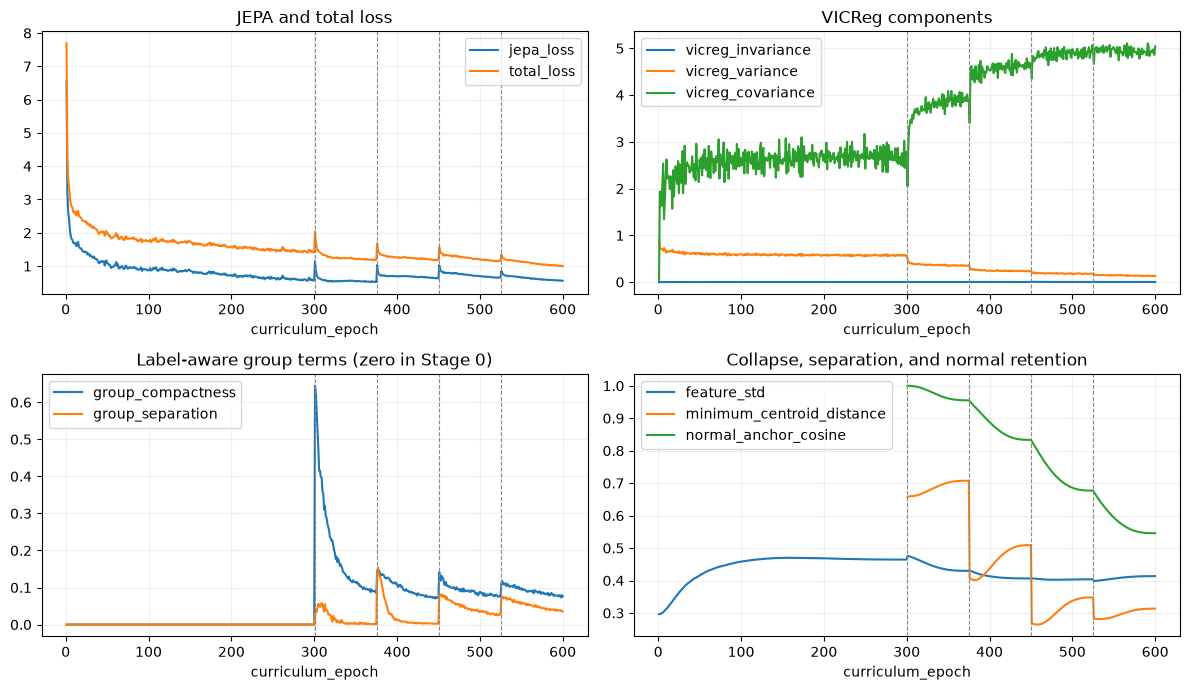

In [16]:
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history_rows).reset_index(drop=True)
history_df["curriculum_epoch"] = np.arange(1, len(history_df) + 1)
figure, axes = plt.subplots(2, 2, figsize=(12, 7))
history_df.plot(x="curriculum_epoch", y=["jepa_loss", "total_loss"], ax=axes[0, 0])
history_df.plot(x="curriculum_epoch", y=["vicreg_invariance", "vicreg_variance", "vicreg_covariance"], ax=axes[0, 1])
history_df.plot(x="curriculum_epoch", y=["group_compactness", "group_separation"], ax=axes[1, 0])
history_df.plot(x="curriculum_epoch", y=["feature_std", "minimum_centroid_distance", "normal_anchor_cosine"], ax=axes[1, 1])
axes[0, 0].set_title("JEPA and total loss")
axes[0, 1].set_title("VICReg components")
axes[1, 0].set_title("Label-aware group terms (zero in Stage 0)")
axes[1, 1].set_title("Collapse, separation, and normal retention")
for axis in axes.flat:
    for boundary in history_df.groupby("stage")["curriculum_epoch"].min().iloc[1:]:
        axis.axvline(boundary - 0.5, color="#888888", linestyle="--", linewidth=0.8)
    axis.grid(alpha=0.2)
figure.tight_layout()
figure.savefig(
    ARTIFACT_DIR / cohort_artifact_name("curriculum_training_diagnostics.png", augmented=bool(aug_records)),
    dpi=180,
    bbox_inches="tight",
)
plt.show()


## How to read the results without overclaiming

- A finite or falling JEPA loss says the predictor is matching the teacher better; it does not prove useful gait semantics.
- A feature standard deviation near zero, VICReg variance hinge that stays high, or pairwise cosine near one warns about collapse.
- The minimum centroid distance should be read together with within-group compactness. A margin penalty near zero means the training constraint is satisfied on this corpus, not that unseen people will separate.
- `normal_anchor_cosine` tracks how much the normal representation moves after each added condition. A sharp fall suggests forgetting despite replay.
- Stage 0 is label-free with respect to condition separation. Stages 1–4 are label-aware because the group loss uses folder annotations.
- Existing repository metrics from the earlier 10-keypoint, normal-only checkpoint are a legacy baseline. They are not results for this revised model. Do not report new accuracy, robustness, or capacity claims until notebooks 04–06 have been rerun and the checkpoint fingerprint is recorded.
- Because the final encoder has seen the progressive corpus and its condition labels, a Random Forest split over those same rows is a descriptive readout, not a held-out generalization test. A valid estimate requires fitting the entire curriculum inside each source-video training fold.
